<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/ISE-201-Math-Foundations-for-Decision-Data-Sciences/blob/main/code_for_hw5_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from scipy.optimize import linprog

# The problem is: Maximize Z = x1 + 2*x2
# We convert this to minimization: Minimize -Z = -x1 - 2*x2
c = [-1, -2]

# Constraints in the form A_ub * x <= b_ub
# 1. x1 <= 2
# 2. x2 <= 2
# 3. x1 + x2 <= 3
A_ub = [
    [1, 0],
    [0, 1],
    [1, 1]
]

b_ub = [2, 2, 3]

# Non-negativity constraints: x1 >= 0, x2 >= 0
# The default bounds for linprog are (0, None), so we explicitly set them for clarity.
x1_bounds = (0, None)
x2_bounds = (0, None)
bounds = [x1_bounds, x2_bounds]

# Solve the linear programming problem
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# The optimal Z value is the negative of the minimized objective value
optimal_Z = -result.fun

print("--- Optimization Result ---")
print(f"Success: {result.success}")
print(f"Status: {result.message}")
print("\nOptimal Solution:")
print(f"x1 (Optimal Hot Dogs): {result.x[0]:.4f}")
print(f"x2 (Optimal Hot Dog Buns): {result.x[1]:.4f}")
print(f"Maximum Z (Profit): {optimal_Z:.4f}")

# Check the utilization of the resources (Slack values)
# Slack = b_ub - A_ub * x
slack = b_ub - (A_ub @ result.x)
print("\nConstraint Utilization (Slack):")
print(f"Constraint 1 (x1 <= 2) Slack: {slack[0]:.4f}")
print(f"Constraint 2 (x2 <= 2) Slack: {slack[1]:.4f}")
print(f"Constraint 3 (x1 + x2 <= 3) Slack: {slack[2]:.4f}")

--- Optimization Result ---
Success: True
Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimal Solution:
x1 (Optimal Hot Dogs): 1.0000
x2 (Optimal Hot Dog Buns): 2.0000
Maximum Z (Profit): 5.0000

Constraint Utilization (Slack):
Constraint 1 (x1 <= 2) Slack: 1.0000
Constraint 2 (x2 <= 2) Slack: 0.0000
Constraint 3 (x1 + x2 <= 3) Slack: 0.0000


In [2]:
from scipy.optimize import linprog

# Objective function coefficients (for MAXIMIZATION Z = x1 + 2x2, we MINIMIZE -Z = -x1 - 2x2)
c = [-1, -2]

# Coefficients of the inequality constraints (A_ub @ x <= b_ub)
# 1. x1 <= 2
# 2. x2 <= 2
# 3. x1 + x2 <= 3
A_ub = [
    [1, 0],  # Constraint 1: x1 <= 2
    [0, 1],  # Constraint 2: x2 <= 2
    [1, 1]   # Constraint 3: x1 + x2 <= 3
]

# Right-hand side of the inequality constraints
b_ub = [2, 2, 3]

# Bounds for variables (x1 >= 0, x2 >= 0)
x1_bounds = (0, None)
x2_bounds = (0, None)

# Solve the minimization problem
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[x1_bounds, x2_bounds], method='highs')

# Check if the optimization was successful
if result.success:
    # The optimal Z value is the negative of the minimized value
    max_z = -result.fun
    x1_optimal = result.x[0]
    x2_optimal = result.x[1]

    print(f"Optimization Status: Success")
    print(f"Optimal solution found at:")
    print(f"  x1 = {x1_optimal:.2f}")
    print(f"  x2 = {x2_optimal:.2f}")
    print(f"  Maximum Z = {max_z:.2f}")
else:
    print(f"Optimization Status: Failed. Message: {result.message}")

# --- Displaying information about slack variables (how much resource is unused) ---

# The slack variables correspond to A_ub constraints
slack = result.slack

print("\nResource Utilization (Slack/Surplus):")
print(f"  Slack for Constraint 1 (x1 <= 2): {slack[0]:.2f}")
print(f"  Slack for Constraint 2 (x2 <= 2): {slack[1]:.2f}")
print(f"  Slack for Constraint 3 (x1 + x2 <= 3): {slack[2]:.2f}")

Optimization Status: Success
Optimal solution found at:
  x1 = 1.00
  x2 = 2.00
  Maximum Z = 5.00

Resource Utilization (Slack/Surplus):
  Slack for Constraint 1 (x1 <= 2): 1.00
  Slack for Constraint 2 (x2 <= 2): 0.00
  Slack for Constraint 3 (x1 + x2 <= 3): 0.00


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Define the CPF solutions (corner points of the feasible region)
# Vertices must be ordered for plt.fill()
cpf_solutions = {
    'A (0,0)': (0, 0),
    'B (2,0)': (2, 0),
    'C (2,1)': (2, 1),
    'D (1,2) - Optimal': (1, 2),
    'E (0,2)': (0, 2)
}

# Ordered coordinates for shading the feasible region
x_coords = [0, 2, 2, 1, 0, 0]
y_coords = [0, 0, 1, 2, 2, 0]

# --- Plotting ---
plt.figure(figsize=(8, 8))

# 2. Shade the feasible region (Part a)
plt.fill(x_coords, y_coords, color='lightblue', alpha=0.6, label='Feasible Region')

# 3. Plot the Constraint Boundaries (Part a)

# Constraint 1: x1 <= 2 (Vertical line)
plt.plot([2, 2], [0, 3.5], 'r--', label='$x_1 \leq 2$ ($L_1$)')

# Constraint 2: x2 <= 2 (Horizontal line)
plt.plot([0, 3.5], [2, 2], 'g--', label='$x_2 \leq 2$ ($L_2$)')

# Constraint 3: x1 + x2 <= 3 (Line: x2 = 3 - x1)
x_line3 = np.linspace(0, 3, 100)
y_line3 = 3 - x_line3
plt.plot(x_line3, y_line3, 'm--', label='$x_1 + x_2 \leq 3$ ($L_3$)')

# Non-negativity constraints (axes)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)


# 4. Plot the CPF Solutions (Part a, b, c)
for label, (x1, x2) in cpf_solutions.items():
    plt.plot(x1, x2, 'o', color='k', markersize=8, markeredgecolor='black', zorder=5)
    # Add labels for the CPF solutions
    plt.text(x1 + 0.05, x2 + 0.05, label.split(' ')[0], fontsize=12, ha='left')

# 5. Plot the Optimal Isoprofit Line (Z = 5)
# Equation: x1 + 2x2 = 5 => x2 = 2.5 - 0.5*x1
x_iso = np.linspace(0, 5, 100)
y_iso = 2.5 - 0.5 * x_iso
# Only plot the segment that intersects the feasible region
plt.plot(x_iso[(x_iso >= 0) & (y_iso >= 0)], y_iso[(x_iso >= 0) & (y_iso >= 0)],
         '--', color='orange', linewidth=2, label='Optimal Isoprofit ($Z=5$)')

# 6. Add labels and titles
plt.title('Feasible Region and CPF Solutions for Max $Z = x_1 + 2x_2$', fontsize=14)
plt.xlabel('$x_1$ (Variable 1)', fontsize=12)
plt.ylabel('$x_2$ (Variable 2)', fontsize=12)
plt.xlim(-0.1, 3.5)
plt.ylim(-0.1, 3.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.gca().set_aspect('equal', adjustable='box')

# 7. Save the figure
plt.savefig('lp_problem_4_1_1_solution.png')
plt.close()

print("CPF Solutions and their binding constraints (from previous analysis):")
cpf_data = {
    'CPF Solution': ['A (0, 0)', 'B (2, 0)', 'C (2, 1)', 'D (1, 2)', 'E (0, 2)'],
    'Binding Constraints': ['$x_1=0$, $x_2=0$', '$x_1=2$, $x_2=0$', '$x_1=2$, $x_1+x_2=3$', '$x_2=2$, $x_1+x_2=3$', '$x_1=0$, $x_2=2$'],
    'Adjacent CPF Solutions': ['B, E', 'A, C', 'B, D', 'C, E', 'A, D'],
    'Shared Constraint Boundary': ['$x_2=0$, $x_1=0$', '$x_2=0$, $x_1=2$', '$x_1=2$, $x_1+x_2=3$', '$x_1+x_2=3$, $x_2=2$', '$x_2=2$, $x_1=0$']
}
df = pd.DataFrame(cpf_data)
print(df.to_markdown(index=False))

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2987873614.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.plot([2, 2], [0, 3.5], 'r--', label='$x_1 \leq 2$ ($L_1$)')
/tmp/ipython-input-2987873614.py:31: SyntaxWarning: invalid escape sequence '\l'
  plt.plot([0, 3.5], [2, 2], 'g--', label='$x_2 \leq 2$ ($L_2$)')
/tmp/ipython-input-2987873614.py:36: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_line3, y_line3, 'm--', label='$x_1 + x_2 \leq 3$ ($L_3$)')


CPF Solutions and their binding constraints (from previous analysis):
| CPF Solution   | Binding Constraints   | Adjacent CPF Solutions   | Shared Constraint Boundary   |
|:---------------|:----------------------|:-------------------------|:-----------------------------|
| A (0, 0)       | $x_1=0$, $x_2=0$      | B, E                     | $x_2=0$, $x_1=0$             |
| B (2, 0)       | $x_1=2$, $x_2=0$      | A, C                     | $x_2=0$, $x_1=2$             |
| C (2, 1)       | $x_1=2$, $x_1+x_2=3$  | B, D                     | $x_1=2$, $x_1+x_2=3$         |
| D (1, 2)       | $x_2=2$, $x_1+x_2=3$  | C, E                     | $x_1+x_2=3$, $x_2=2$         |
| E (0, 2)       | $x_1=0$, $x_2=2$      | A, D                     | $x_2=2$, $x_1=0$             |


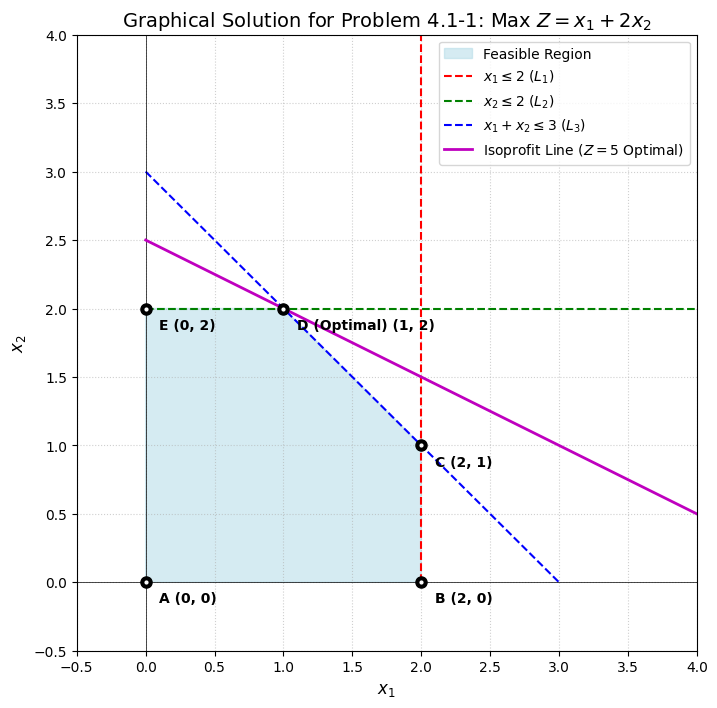

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the feasible region vertices (CPF solutions) in order for plt.fill()
# A(0, 0), B(2, 0), C(2, 1), D(1, 2), E(0, 2)
cpf_x = [0, 2, 2, 1, 0]
cpf_y = [0, 0, 1, 2, 2]
cpf_labels = ['A', 'B', 'C', 'D (Optimal)', 'E']

# 2. Define the plot range
x_max = 4
y_max = 4
x = np.linspace(0, x_max, 500)

# 3. Define the constraint boundary lines
# L1: x1 = 2
# L2: x2 = 2
# L3: x1 + x2 = 3 => x2 = 3 - x1

# --- Plotting ---
plt.figure(figsize=(8, 8))

# a. Plot the Feasible Region
plt.fill(cpf_x, cpf_y, color='lightblue', alpha=0.5, label='Feasible Region')

# Plot Constraint Boundary Lines using raw strings (r'...') and LaTeX for the labels
# Fixes the SyntaxWarning by correctly handling the backslash in \le and \l
plt.plot([2, 2], [0, y_max], 'r--', label=r'$x_1 \leq 2$ ($L_1$)') # x1 = 2
plt.plot([0, x_max], [2, 2], 'g--', label=r'$x_2 \leq 2$ ($L_2$)') # x2 = 2

# For L3, only plot the relevant segment
x_l3 = np.linspace(0, 3, 500)
y_l3 = 3 - x_l3
plt.plot(x_l3, y_l3, 'b--', label=r'$x_1 + x_2 \leq 3$ ($L_3$)')

# Plot Non-negativity constraints (axes)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)

# b, c. Plot and Label CPF Solutions
for i in range(len(cpf_x)):
    # Plot the point
    plt.plot(cpf_x[i], cpf_y[i], 'ko', markersize=8, zorder=5) # Black circle for the point
    plt.plot(cpf_x[i], cpf_y[i], 'w.', markersize=4, zorder=6) # White dot in the middle

    # Label the point
    plt.text(cpf_x[i] + 0.1, cpf_y[i] - 0.15,
             f'{cpf_labels[i]} ({cpf_x[i]}, {cpf_y[i]})',
             fontsize=10, weight='bold')

# Optimal Objective Function Line (Z=5)
# x1 + 2x2 = 5 => x2 = 2.5 - 0.5*x1
x_opt = np.linspace(0, 5, 500)
y_opt = 2.5 - 0.5 * x_opt
# Only plot the part that is visible in the graph window
x_opt_visible = x_opt[(x_opt >= 0) & (y_opt >= 0) & (x_opt <= x_max) & (y_opt <= y_max)]
y_opt_visible = y_opt[(x_opt >= 0) & (y_opt >= 0) & (x_opt <= x_max) & (y_opt <= y_max)]
plt.plot(x_opt_visible, y_opt_visible, 'm-', linewidth=2, label=r'Isoprofit Line ($Z=5$ Optimal)')


# --- Customization ---
plt.title(r'Graphical Solution for Problem 4.1-1: Max $Z = x_1 + 2x_2$', fontsize=14)
plt.xlabel(r'$x_1$', fontsize=12)
plt.ylabel(r'$x_2$', fontsize=12)
plt.xlim(-0.5, x_max)
plt.ylim(-0.5, y_max)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()

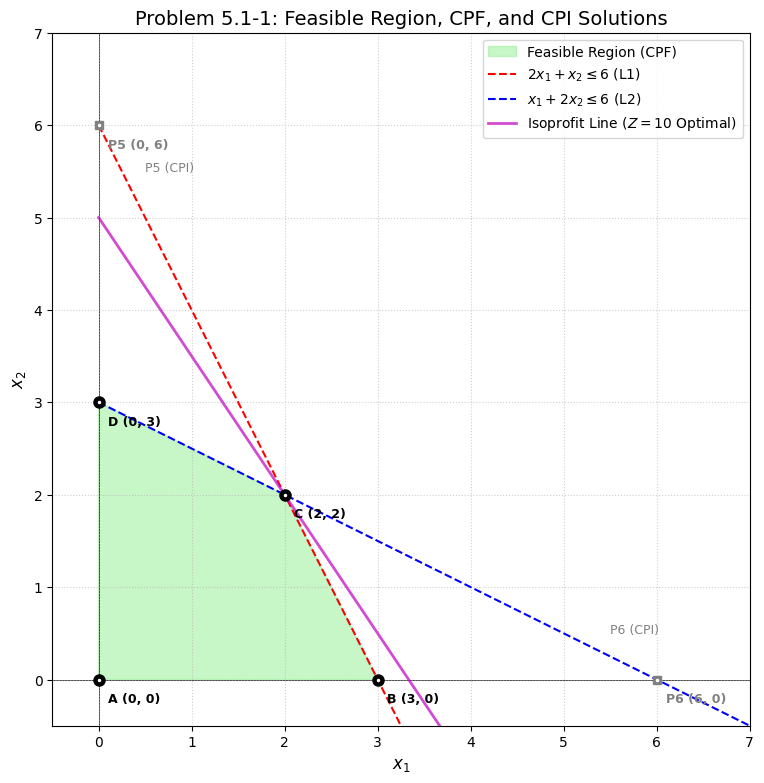

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# LP Problem 5.1-1: Max Z = 3x1 + 2x2
# Constraints:
# L1: 2x1 + x2 <= 6  => x2 = 6 - 2x1
# L2: x1 + 2x2 <= 6  => x2 = 3 - 0.5x1
# Non-negativity: x1 >= 0, x2 >= 0

# --- Defining all Corner-Point Solutions (CPF and CPI) ---
# Intersection of 2 out of 4 boundaries (x1=0, x2=0, L1, L2)

# Boundary Equations:
# B0: x1 = 0
# B1: x2 = 0
# B2: 2x1 + x2 = 6
# B3: x1 + 2x2 = 6

# Corner Points (6 total sets):
# A (B0, B1): x1=0, x2=0              -> (0, 0)
# B (B1, B2): x2=0, 2x1+0=6          -> (3, 0)
# D (B0, B3): x1=0, 0+2x2=6          -> (0, 3)
# C (B2, B3): 2x1+x2=6, x1+2x2=6     -> (2, 2)
# P5 (B0, B2): x1=0, 0+x2=6          -> (0, 6)
# P6 (B1, B3): x2=0, x1+0=6          -> (6, 0)

# Data for all 6 corner points:
cpf_data = pd.DataFrame({
    'Label': ['A', 'B', 'C', 'D', 'P5', 'P6'],
    'x1': [0, 3, 2, 0, 0, 6],
    'x2': [0, 0, 2, 3, 6, 0],
    'Type': ['CPF', 'CPF', 'CPF', 'CPF', 'CPI', 'CPI'],
    'Z_Value': [0, 9, 10, 6, 18, 18] # Z = 3x1 + 2x2
})

# Filter CPF solutions for shading the feasible region
cpf_feasible_x = cpf_data[cpf_data['Type'] == 'CPF']['x1'].tolist()
cpf_feasible_y = cpf_data[cpf_data['Type'] == 'CPF']['x2'].tolist()

# Define plot range
x_max = 7
y_max = 7
x = np.linspace(0, x_max, 500)

# --- Plotting ---
plt.figure(figsize=(9, 9))

# a. Plot the Feasible Region (CPF Solutions: A, B, C, D)
plt.fill(cpf_feasible_x, cpf_feasible_y, color='lightgreen', alpha=0.5, label='Feasible Region (CPF)')

# Plot Constraint Boundary Lines
plt.plot(x, 6 - 2 * x, 'r--', label=r'$2x_1 + x_2 \leq 6$ (L1)', zorder=2)
plt.plot(x, 3 - 0.5 * x, 'b--', label=r'$x_1 + 2x_2 \leq 6$ (L2)', zorder=2)

# Plot Non-negativity constraints (axes)
plt.axhline(0, color='k', linewidth=0.5, zorder=1)
plt.axvline(0, color='k', linewidth=0.5, zorder=1)

# Plot Optimal Isoprofit Line (Z=10)
# x2 = 5 - 1.5*x1
x_opt = np.linspace(0, 10, 500)
y_opt = 5 - 1.5 * x_opt
plt.plot(x_opt, y_opt, 'm-', linewidth=2, alpha=0.7, label=r'Isoprofit Line ($Z=10$ Optimal)', zorder=3)


# b. Plot all 6 Corner-Point Solutions (CPF and CPI)
for index, row in cpf_data.iterrows():
    color = 'k' if row['Type'] == 'CPF' else 'gray'
    marker = 'o' if row['Type'] == 'CPF' else 's'
    size = 8 if row['Type'] == 'CPF' else 6
    zorder = 5 if row['Type'] == 'CPF' else 4

    # Plot the point
    plt.plot(row['x1'], row['x2'], marker, color=color, markersize=size, zorder=zorder)
    plt.plot(row['x1'], row['x2'], 'w.', markersize=3, zorder=zorder + 1) # White dot in the middle

    # Label the point
    label_text = f"{row['Label']} ({row['x1']}, {row['x2']})"
    plt.text(row['x1'] + 0.1, row['x2'] - 0.25, label_text, fontsize=9, weight='bold', color=color)

# Add annotations for CPI solutions for clarity (optional, but helpful)
plt.text(5.5, 0.5, "P6 (CPI)", fontsize=9, color='gray')
plt.text(0.5, 5.5, "P5 (CPI)", fontsize=9, color='gray')


# --- Customization ---
plt.title(r'Problem 5.1-1: Feasible Region, CPF, and CPI Solutions', fontsize=14)
plt.xlabel(r'$x_1$', fontsize=12)
plt.ylabel(r'$x_2$', fontsize=12)
plt.xlim(-0.5, x_max)
plt.ylim(-0.5, y_max)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()